In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore


In [34]:
# Đọc file giá/lịch sử giao dịch TSLA
df = pd.read_csv("TSLA_history_2015-2025.csv")

In [35]:
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-12-31,14.87,15.05,14.82,14.83,14.83,34462500
1,2015-01-02,14.86,14.88,14.22,14.62,14.62,71466000
2,2015-01-05,14.30,14.43,13.81,14.01,14.01,80527500
3,2015-01-06,14.00,14.28,13.61,14.09,14.09,93928500
4,2015-01-07,14.22,14.32,13.99,14.06,14.06,44526000
...,...,...,...,...,...,...,...
2619,2025-06-02,343.50,348.02,333.33,342.69,342.69,81873800
2620,2025-06-03,346.60,355.40,343.04,344.27,344.27,99324500
2621,2025-06-04,345.10,345.60,327.33,332.05,332.05,98912100
2622,2025-06-05,322.49,324.55,273.21,284.70,284.70,287499800


In [36]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2624 entries, 0 to 2623
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2624 non-null   object 
 1   Open       2624 non-null   float64
 2   High       2624 non-null   float64
 3   Low        2624 non-null   float64
 4   Close      2624 non-null   float64
 5   Adj Close  2624 non-null   float64
 6   Volume     2624 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 143.6+ KB


In [38]:
# Chuyển cột 'Date' sang kiểu datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2624 entries, 0 to 2623
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2624 non-null   datetime64[ns]
 1   Open       2624 non-null   float64       
 2   High       2624 non-null   float64       
 3   Low        2624 non-null   float64       
 4   Close      2624 non-null   float64       
 5   Adj Close  2624 non-null   float64       
 6   Volume     2624 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 143.6 KB


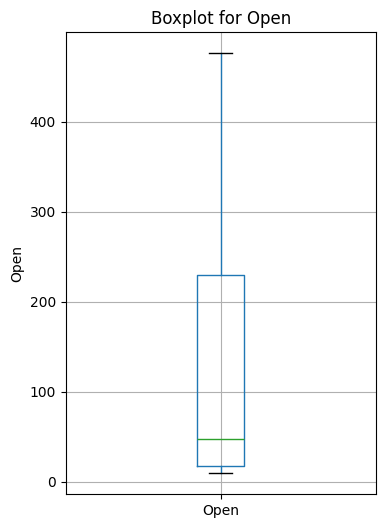

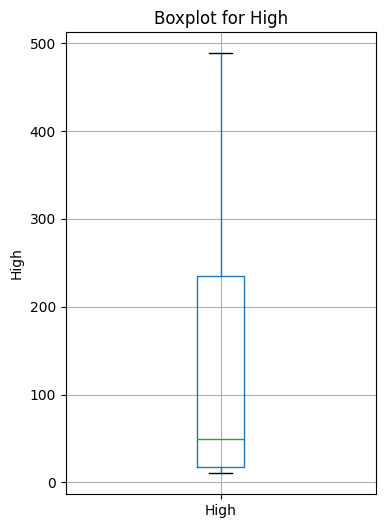

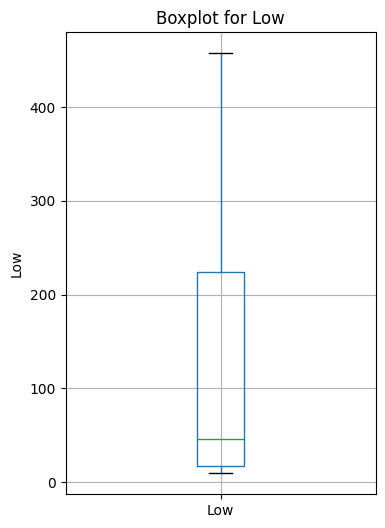

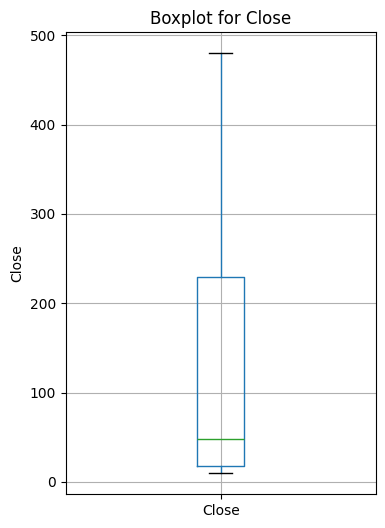

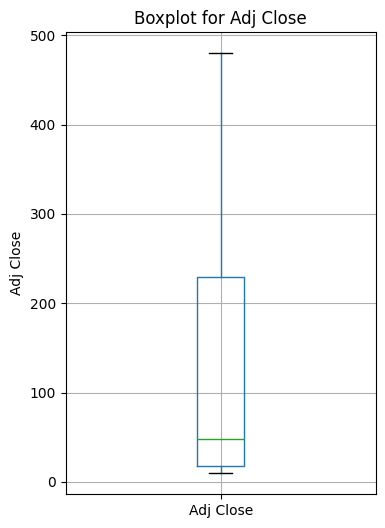

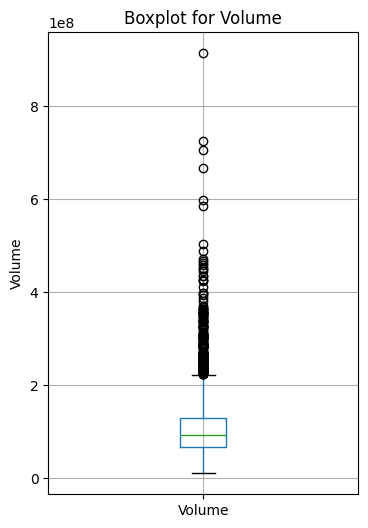

In [40]:
# Danh sách cột muốn vẽ
cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

for col in cols:
    if col in df.columns:  # Kiểm tra cột có tồn tại không
        plt.figure(figsize=(4, 6))
        df.boxplot(column=[col])
        plt.title(f'Boxplot for {col}')
        plt.ylabel(col)
        plt.show()
    else:
        print(f"Cột '{col}' không tồn tại trong DataFrame.")

In [41]:
# Bước 1: Loại outlier cho cột Volume bằng IQR (lọc trực tiếp trên df)
Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Volume'] >= lower_bound) & (df['Volume'] <= upper_bound)]

In [42]:
# Chọn các cột muốn chuẩn hóa
cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

# Chuẩn hóa z-score cho từng cột (giá trị mới mean=0, std=1)
df[cols] = df[cols].apply(lambda x: (x - x.mean()) / x.std())

# Kiểm tra lại
print(df[cols].describe())

               Open          High           Low        Close    Adj Close  \
count  2.440000e+03  2.440000e+03  2.440000e+03  2440.000000  2440.000000   
mean  -1.863719e-16  2.795578e-16 -9.318593e-17     0.000000     0.000000   
std    1.000000e+00  1.000000e+00  1.000000e+00     1.000000     1.000000   
min   -9.779687e-01 -9.717091e-01 -9.789581e-01    -0.977774    -0.977774   
25%   -9.145344e-01 -9.142598e-01 -9.154512e-01    -0.915159    -0.915159   
50%   -6.302823e-01 -6.316734e-01 -6.296698e-01    -0.630597    -0.630597   
75%    8.748380e-01  8.704056e-01  8.845456e-01     0.882433     0.882433   
max    2.855705e+00  2.870646e+00  2.800339e+00     2.891647     2.891647   

             Volume  
count  2.440000e+03  
mean  -1.164824e-17  
std    1.000000e+00  
min   -2.053780e+00  
25%   -7.434843e-01  
50%   -1.834410e-01  
75%    5.450730e-01  
max    2.967441e+00  


C:\Users\tho\AppData\Local\Temp\ipykernel_22844\548760911.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[cols] = df[cols].apply(lambda x: (x - x.mean()) / x.std())


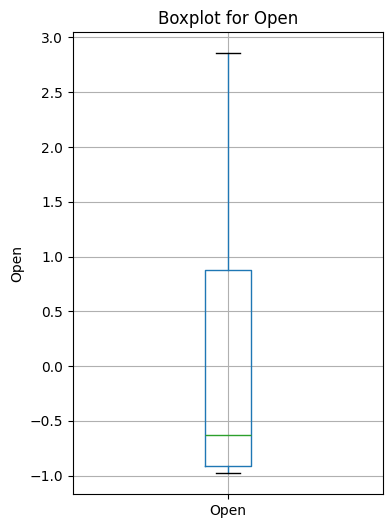

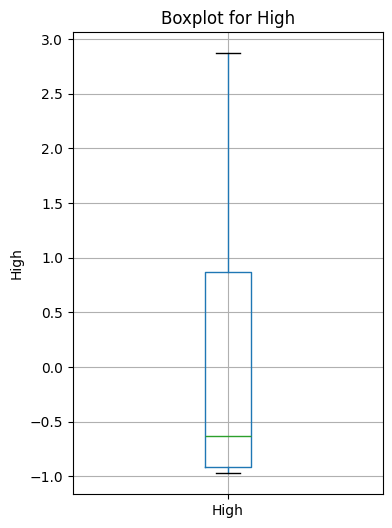

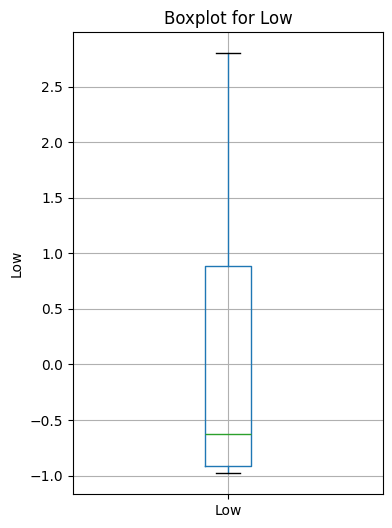

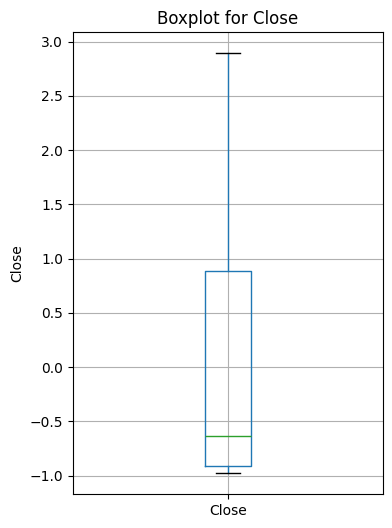

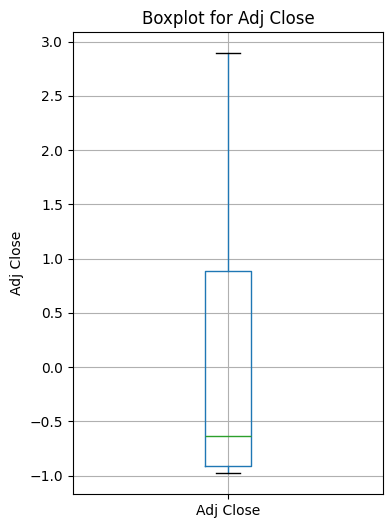

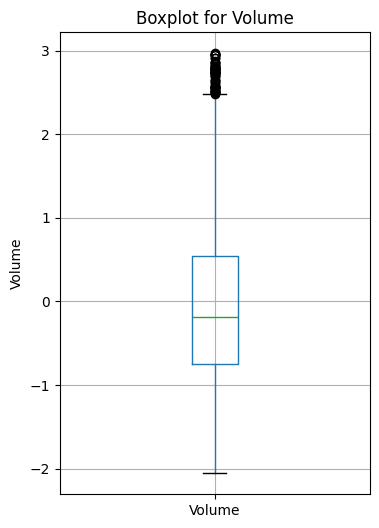

In [43]:
# Danh sách cột muốn vẽ
cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

for col in cols:
    if col in df.columns:  # Kiểm tra cột có tồn tại không
        plt.figure(figsize=(4, 6))
        df.boxplot(column=[col])
        plt.title(f'Boxplot for {col}')
        plt.ylabel(col)
        plt.show()
    else:
        print(f"Cột '{col}' không tồn tại trong DataFrame.")

In [44]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,2440,2.440000e+03,2.440000e+03,2.440000e+03,2440.000000,2440.000000,2.440000e+03
mean,2020-03-24 23:42:17.704918016,-1.863719e-16,2.795578e-16,-9.318593e-17,0.000000,0.000000,-1.164824e-17
min,2014-12-31 00:00:00,-9.779687e-01,-9.717091e-01,-9.789581e-01,-0.977774,-0.977774,-2.053780e+00
25%,2017-06-12 18:00:00,-9.145344e-01,-9.142598e-01,-9.154512e-01,-0.915159,-0.915159,-7.434843e-01
50%,2020-04-22 12:00:00,-6.302823e-01,-6.316734e-01,-6.296698e-01,-0.630597,-0.630597,-1.834410e-01
75%,2022-12-16 18:00:00,8.748380e-01,8.704056e-01,8.845456e-01,0.882433,0.882433,5.450730e-01
max,2025-06-06 00:00:00,2.855705e+00,2.870646e+00,2.800339e+00,2.891647,2.891647,2.967441e+00
std,NaN,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000,1.000000e+00


In [45]:
df.to_csv('TSLA_cleaned.csv', index=False)